In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROCESSED_DIR = "/content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3"
# SAVE_PATH     = "/content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v3.pth"

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from collections import defaultdict

BATCH_SIZE   = 8
NUM_WORKERS  = 2
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
mal_files  = [f for f in os.listdir(f"{PROCESSED_DIR}/malpractice") if f.endswith(".npy")]
norm_files = [f for f in os.listdir(f"{PROCESSED_DIR}/no_malpractice") if f.endswith(".npy")]

print(f"Malpractice files  : {len(mal_files)}")
print(f"No-malpractice files: {len(norm_files)}")

# check a malpractice file raw
sample = np.load(f"{PROCESSED_DIR}/malpractice/{mal_files[0]}")
print(f"\nMal sample  — min: {sample.min():.5f}  max: {sample.max():.5f}")

# check a no_malpractice file raw
sample2 = np.load(f"{PROCESSED_DIR}/no_malpractice/{norm_files[0]}")
print(f"Norm sample — min: {sample2.min():.5f}  max: {sample2.max():.5f}")

Malpractice files  : 63
No-malpractice files: 64

Mal sample  — min: 0.00000  max: 1.00000
Norm sample — min: 0.00000  max: 1.00000


In [ ]:
all_clips  = []
all_labels = []

for clip in os.listdir(f"{PROCESSED_DIR}/malpractice"):
    if clip.endswith(".npy") and "_flip" not in clip and "_bright" not in clip:
        all_clips.append(f"{PROCESSED_DIR}/malpractice/{clip}")
        all_labels.append(1)

for clip in os.listdir(f"{PROCESSED_DIR}/no_malpractice"):
    if clip.endswith(".npy") and "_flip" not in clip and "_bright" not in clip:
        all_clips.append(f"{PROCESSED_DIR}/no_malpractice/{clip}")
        all_labels.append(0)

print(f"Total clips     : {len(all_clips)}")
print(f"Malpractice [1] : {sum(all_labels)}")
print(f"Normal      [0] : {len(all_labels) - sum(all_labels)}")

Total clips     : 127
Malpractice [1] : 63
Normal      [0] : 64


In [ ]:
import random
random.seed(42)

mal_clips_list  = [(p, 1) for p, l in zip(all_clips, all_labels) if l == 1]
norm_clips_list = [(p, 0) for p, l in zip(all_clips, all_labels) if l == 0]

# ✅ No capping — keep all 118 clips (63 vs 55 is close enough)
print(f"Malpractice : {len(mal_clips_list)}")
print(f"Normal      : {len(norm_clips_list)}")

def get_video_dict(clips_labels):
    vdict = defaultdict(list)
    for path, label in clips_labels:
        vid = os.path.basename(path).split("_clip_")[0]
        vdict[vid].append((path, label))
    return vdict

mal_vdict  = get_video_dict(mal_clips_list)
norm_vdict = get_video_dict(norm_clips_list)

def split_videos(vdict, seed=42):
    vids = list(vdict.keys())
    tr, tmp = train_test_split(vids, test_size=0.30, random_state=seed)
    va, te  = train_test_split(tmp,  test_size=0.50, random_state=seed)
    return tr, va, te

mal_train,  mal_val,  mal_test  = split_videos(mal_vdict)
norm_train, norm_val, norm_test = split_videos(norm_vdict)

def expand(vdict, vids):
    clips, labels = [], []
    for v in vids:
        for path, label in vdict[v]:
            clips.append(path)
            labels.append(label)
    return clips, labels

X_train = expand(mal_vdict, mal_train)[0] + expand(norm_vdict, norm_train)[0]
y_train = expand(mal_vdict, mal_train)[1] + expand(norm_vdict, norm_train)[1]
X_val   = expand(mal_vdict, mal_val)[0]   + expand(norm_vdict, norm_val)[0]
y_val   = expand(mal_vdict, mal_val)[1]   + expand(norm_vdict, norm_val)[1]
X_test  = expand(mal_vdict, mal_test)[0]  + expand(norm_vdict, norm_test)[0]
y_test  = expand(mal_vdict, mal_test)[1]  + expand(norm_vdict, norm_test)[1]

print(f"\nTrain — 0: {y_train.count(0)}  1: {y_train.count(1)}")
print(f"Val   — 0: {y_val.count(0)}    1: {y_val.count(1)}")
print(f"Test  — 0: {y_test.count(0)}   1: {y_test.count(1)}")

Malpractice : 63
Normal      : 64

Train — 0: 44  1: 44
Val   — 0: 10    1: 9
Test  — 0: 10   1: 10


In [ ]:
import numpy as np

mal_sample  = np.load(X_train[y_train.index(1)])
norm_sample = np.load(X_train[y_train.index(0)])

print(f"Mal  — shape: {mal_sample.shape}  min: {mal_sample.min():.5f}  max: {mal_sample.max():.5f}")
print(f"Norm — shape: {norm_sample.shape}  min: {norm_sample.min():.5f}  max: {norm_sample.max():.5f}")

Mal  — shape: (64, 112, 112, 3)  min: 0.00000  max: 1.00000
Norm — shape: (64, 112, 112, 3)  min: 0.00000  max: 1.00000


In [ ]:
def augment_clip(clip):
    rgb    = clip[..., :3]
    motion = clip[..., 3:] if clip.shape[-1] > 3 else np.zeros_like(rgb)

    if np.random.rand() < 0.5:
        rgb    = rgb[:, :, ::-1, :]
        motion = motion[:, :, ::-1, :]

    factor = np.random.uniform(0.8, 1.2)
    rgb    = np.clip(rgb * factor, 0.0, 1.0)

    if np.random.rand() < 0.5:
        noise = np.random.normal(0, 0.02, rgb.shape).astype(np.float32)
        rgb   = np.clip(rgb + noise, 0.0, 1.0)

    return np.concatenate([rgb, motion], axis=-1)


class MalpracticeDataset(Dataset):
    def __init__(self, clip_paths, labels, augment=False):
        self.clip_paths = clip_paths
        self.labels     = labels
        self.augment    = augment

    def __len__(self):
        return len(self.clip_paths)

    def __getitem__(self, idx):
        try:
            clip = np.load(self.clip_paths[idx])
        except:
            clip = np.zeros((64, 112, 112, 3), dtype=np.float32)

        # ✅ REMOVED: label-based * 255.0 fix (not needed for new clean data)

        clip = np.clip(clip, 0.0, 1.0)

        if clip.shape[-1] == 3:
            clip = np.concatenate([clip, np.zeros_like(clip)], axis=-1)

        # ✅ FIXED: augment both classes, not just malpractice
        if self.augment:
            clip = augment_clip(clip)

        clip  = np.transpose(clip, (0, 3, 1, 2))
        clip  = torch.from_numpy(clip.copy()).float()
        label = torch.tensor(self.labels[idx], dtype=torch.float32).unsqueeze(0)

        return clip, label


# Weighted sampler
class_counts   = [y_train.count(0), y_train.count(1)]
class_weights  = [1.0 / c for c in class_counts]
sample_weights = [class_weights[y] for y in y_train]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = MalpracticeDataset(X_train, y_train, augment=True)
val_dataset   = MalpracticeDataset(X_val,   y_val,   augment=False)
test_dataset  = MalpracticeDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 11 | Val: 3 | Test: 3


In [ ]:
class LightweightMalpracticeModel(nn.Module):
    def __init__(self):
        super().__init__()

        base_model = torchvision.models.mobilenet_v2(
            weights=torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
        )

        first_conv = base_model.features[0][0]
        new_conv   = nn.Conv2d(6, first_conv.out_channels,
                               kernel_size=first_conv.kernel_size,
                               stride=first_conv.stride,
                               padding=first_conv.padding,
                               bias=False)

        with torch.no_grad():
            new_conv.weight[:, :3] = first_conv.weight
            new_conv.weight[:, 3:] = first_conv.weight

        base_model.features[0][0] = new_conv
        self.cnn = base_model.features

        # ✅ Freeze ALL CNN layers — dataset still small
        for param in self.cnn.parameters():
            param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ✅ Simpler head with stronger dropout to reduce overfitting
        self.classifier = nn.Sequential(
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x     = x.view(B * T, C, H, W)
        feats = self.cnn(x)
        feats = self.pool(feats).view(B, T, -1)

        mean_pool = feats.mean(dim=1)
        max_pool  = feats.max(dim=1).values
        feats     = 0.5 * mean_pool + 0.5 * max_pool

        return self.classifier(feats)


model = LightweightMalpracticeModel().to(device)
# Unfreeze last 3 blocks of CNN
for i, layer in enumerate(model.cnn):
    if i >= 16:  # unfreeze blocks 16, 17, 18
        for param in layer.parameters():
            param.requires_grad = True

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


Trainable params: 1,370,177


In [ ]:
n_neg = y_train.count(0)
n_pos = y_train.count(1)

pos_weight = torch.tensor([n_neg / n_pos]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,          # low LR since we're fine-tuning
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
print("✅ Ready")

✅ Ready


In [ ]:
# Run this first to delete the bad checkpoint
import os
if os.path.exists(SAVE_PATH):
    os.remove(SAVE_PATH)
    print("✅ Bad checkpoint deleted")

NameError: name 'SAVE_PATH' is not defined

In [ ]:
import time

SAVE_PATH     = "/content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v4.pth"

EPOCHS     = 50
EARLY_STOP = 10

history = {
    "train_loss": [],
    "train_acc":  [],
    "val_loss":   [],
    "val_acc":    []
}

best_val_loss    = float("inf")
patience_counter = 0
start_epoch      = 1

if os.path.exists(SAVE_PATH):
    checkpoint = torch.load(SAVE_PATH)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch   = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    history       = checkpoint["history"]
    print(f"✅ Resumed training from epoch {start_epoch}")
else:
    print("🆕 No checkpoint found — starting fresh")

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for clips, labels in loader:
        clips, labels = clips.to(device), labels.to(device)

        with torch.set_grad_enabled(training):
            outputs = model(clips)
            loss    = criterion(outputs, labels)

        if training:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        preds    = (torch.sigmoid(outputs) >= 0.5).float()
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
        total_loss += loss.item()

    return total_loss / len(loader), correct / total * 100

print(f"🚀 Training on {device} for up to {EPOCHS} epochs")
print("=" * 70)

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    gap = train_acc - val_acc

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"| Train {train_loss:.4f}/{train_acc:.1f}% "
          f"| Val {val_loss:.4f}/{val_acc:.1f}% "
          f"| Gap {gap:+.1f}% "
          f"| {time.time()-t0:.1f}s")

    torch.save({
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss":   best_val_loss,
        "history":         history
    }, SAVE_PATH)

    print(f"💾 Checkpoint saved → {SAVE_PATH}")

    BEST_MODEL_PATH = "/content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/best_model_v4.pth"

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        # ✅ Save best weights to a SEPARATE file
        torch.save({
            "epoch":           epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_loss":   best_val_loss,
            "history":         history
        }, BEST_MODEL_PATH)
        print(f"🏆 New best model saved (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            print(f"\n⏹ Early stopping at epoch {epoch}")
            break

print(f"\n✅ Training complete. Best val loss: {best_val_loss:.4f}")

✅ Resumed training from epoch 5
🚀 Training on cuda for up to 50 epochs
Epoch [05/50] | Train 0.6753/58.0% | Val 0.5887/73.7% | Gap -15.7% | 12.6s
💾 Checkpoint saved → /content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v4.pth
🏆 New best model saved (val_loss: 0.5887)
Epoch [06/50] | Train 0.6327/64.8% | Val 0.5299/73.7% | Gap -8.9% | 13.3s
💾 Checkpoint saved → /content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v4.pth
🏆 New best model saved (val_loss: 0.5299)
Epoch [07/50] | Train 0.5861/70.5% | Val 0.5246/78.9% | Gap -8.5% | 14.2s
💾 Checkpoint saved → /content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v4.pth
🏆 New best model saved (val_loss: 0.5246)
Epoch [08/50] | Train 0.5366/77.3% | Val 0.4811/73.7% | Gap +3.6% | 13.4s
💾 Checkpoint saved → /content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/model_v4.pth
🏆 New best model saved (val_loss: 0.4811)
Epoch [09/50] | Train 0.5546/77.3% | Val 0.4723/73.7% | Gap +3.6% | 15.5s
💾 Chec

Loaded checkpoint from epoch 19 | best val loss: 0.3874
                precision    recall  f1-score   support

No Malpractice       0.82      0.90      0.86        10
   Malpractice       0.89      0.80      0.84        10

      accuracy                           0.85        20
     macro avg       0.85      0.85      0.85        20
  weighted avg       0.85      0.85      0.85        20



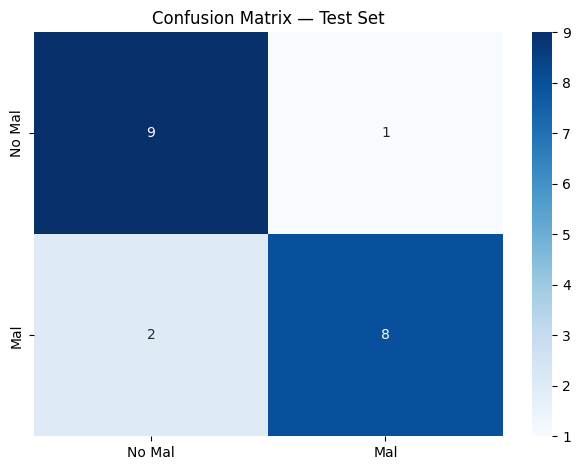

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

BEST_MODEL_PATH = "/content/drive/MyDrive/DEEPLEARNING PROJECT/Processed Data v3/best_model_v4.pth"

# Load best checkpoint
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} | best val loss: {checkpoint['best_val_loss']:.4f}")

all_preds, all_labels_out = [], []

with torch.no_grad():
    for clips, labels in test_loader:
        clips   = clips.to(device)
        outputs = model(clips)
        preds   = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels_out.extend(labels.numpy())

print(classification_report(
    all_labels_out, all_preds,
    target_names=["No Malpractice", "Malpractice"]
))

cm = confusion_matrix(all_labels_out, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Mal", "Mal"],
            yticklabels=["No Mal", "Mal"])
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

In [ ]:
FINAL_MODEL_PATH = "/content/drive/MyDrive/Processed_Data_v2/final_model.pth"

torch.save(model.state_dict(), FINAL_MODEL_PATH)

print(f"✅ Model saved to Google Drive: {FINAL_MODEL_PATH}")

✅ Model saved to Google Drive: /content/drive/MyDrive/Processed_Data_v2/final_model.pth
